<a href="https://colab.research.google.com/github/ggalarza1/AI_Finance/blob/main/AI_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Unsurpervised Learning ---
K-means clustering algorithm. It sorts n observations into k clusters.
This piece of code visualizes clustered sample data and also shows that the scikit-learn KMeans algorithm used here has identified the clusters perfectly.  

Once the algorithm such as KMeans is trained, it can predict the cluster for a new (not yet seen) combination of features values.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns # Import seaborn
from pylab import plt, mpl
sns.set_theme() # Use seaborn's own function to set the theme
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(precision=4, suppress=True)

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

x, y = make_blobs (n_samples=100, centers=4, random_state=500, cluster_std=1.25)

In [ ]:
model = KMeans(n_clusters=4, random_state=0)
model.fit(x)

KMeans(n_clusters=4, random_state=0)

In [ ]:
y_ = model.predict(x)
y_

array([1, 1, 0, 3, 0, 0, 1, 3, 0, 3, 3, 1, 3, 2, 2, 1, 3, 2, 3, 2, 2, 1,
       0, 3, 0, 0, 2, 2, 0, 1, 3, 0, 0, 2, 0, 1, 0, 1, 3, 3, 3, 0, 2, 2,
       1, 0, 3, 2, 3, 2, 1, 2, 0, 2, 0, 1, 0, 3, 2, 1, 0, 2, 1, 3, 1, 2,
       0, 0, 0, 3, 1, 0, 3, 2, 3, 1, 3, 2, 3, 3, 0, 1, 0, 1, 3, 3, 1, 3,
       2, 2, 2, 1, 1, 1, 1, 2, 1, 0, 2, 2], dtype=int32)

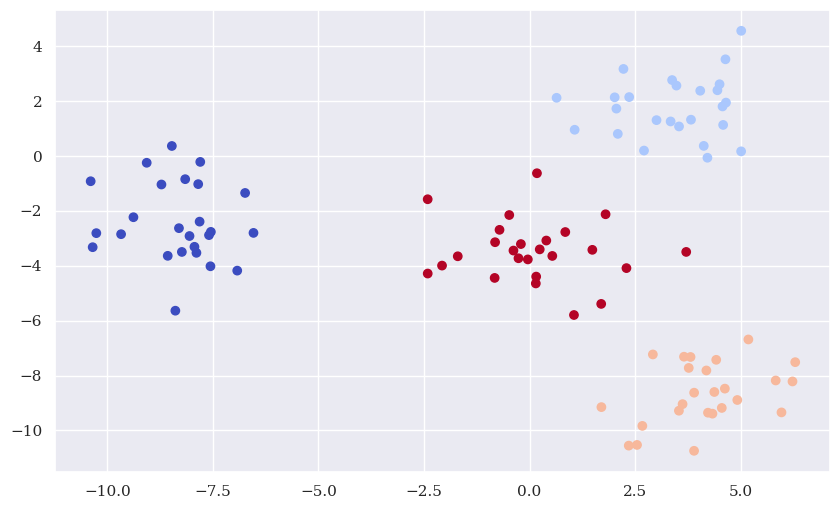

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], x[:, 1], c=y_, cmap='coolwarm')
plt.show()

-- Reinforcement learning -- This is a coin tossing game that is played with a coin that lands 80% of the time on heads and 20% of the time on tails. The baseline algorithm, bets randomly and equally distributes on heads and tails, achieves a total reward of around 50, per epoch of 100 bets played.

In [ ]:
ssp = [1, 1, 1, 1, 0]
asp = [1, 0]
def epoch():
  tr = 0
  for _ in range(100):
    a = np.random.choice(asp)
    s = np.random.choice(ssp)
    if a == s:
      tr += 1
  return tr

In [ ]:
rl = np.array([epoch() for _ in range(15)])
rl

array([50, 48, 51, 56, 52, 50, 62, 47, 49, 54, 32, 57, 51, 52, 47])

In [ ]:
rl.mean()

np.float64(50.53333333333333)

In [ ]:
ssp = [1, 1, 1, 1, 0]

In [ ]:
def epoch():
  tr = 0
  asp = [0, 1]
  for _ in range(100):
    a = np.random.choice(asp)
    s = np.random.choice(ssp)
    if a == s:
      tr += 1
    asp.append(s)
  return tr

In [ ]:
rl = np.array([epoch() for _ in range(15)])
rl

array([64, 71, 69, 64, 70, 55, 50, 73, 56, 67, 69, 69, 59, 66, 71])

In [ ]:
rl.mean()

np.float64(64.86666666666666)

Neural Networks - OLS Regression

In [ ]:
def f(x):
  return 2 * x ** 2 - x ** 3 / 3

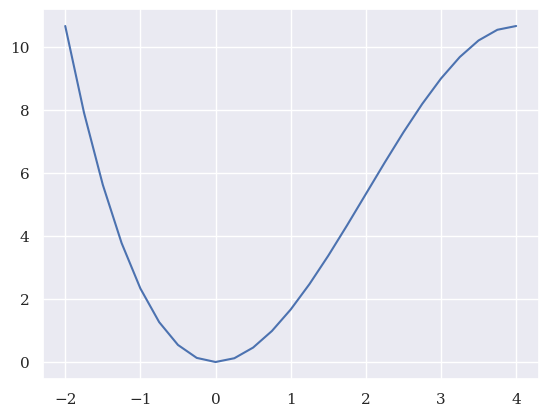

In [ ]:
x = np.linspace(-2, 4, 25)
plt.plot(x, f(x))
plt.show()

In [ ]:
y = f(x)
y

array([10.6667,  7.9115,  5.625 ,  3.776 ,  2.3333,  1.2656,  0.5417,
        0.1302,  0.    ,  0.1198,  0.4583,  0.9844,  1.6667,  2.474 ,
        3.375 ,  4.3385,  5.3333,  6.3281,  7.2917,  8.1927,  9.    ,
        9.6823, 10.2083, 10.5469, 10.6667])

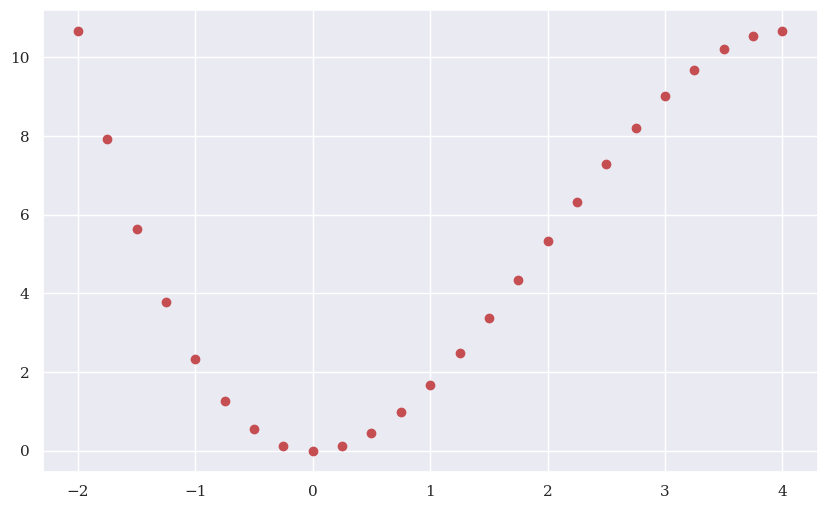

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro')
plt.show()

In [ ]:
beta = np.cov(x, y, ddof=0)[0, 1] / np.var(x)
beta

np.float64(1.0541666666666667)

In [ ]:
alpha = y.mean() - beta * x.mean()
alpha

np.float64(3.8625000000000003)

In [ ]:
y_ = alpha + beta * x

In [ ]:
MSE = ((y - y_) ** 2).mean()
MSE

np.float64(10.721953125)

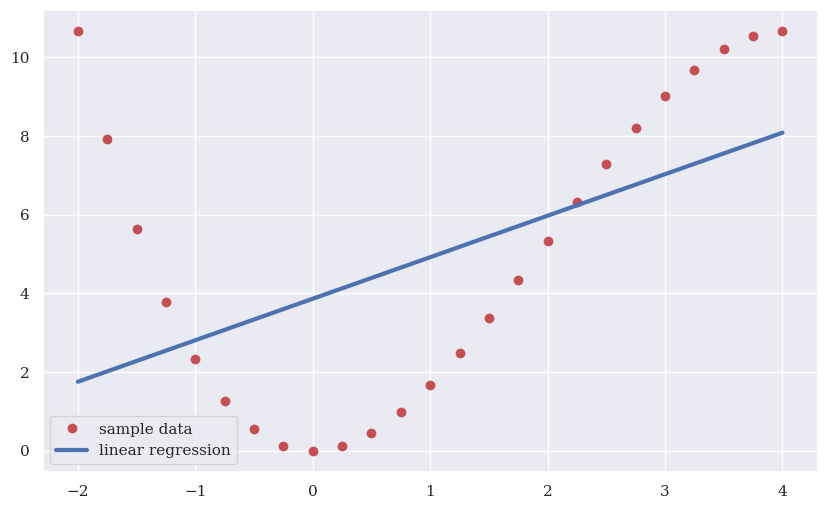

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
plt.plot(x, y_, lw=3.0, label='linear regression')
plt.legend();

Degree 1 (Linear Regression)
Degree 2 (Quadratic Regression)
Degree 3 (Cubic Regression)

deg=1 | MSE=10.72195
deg=2 | MSE=2.31258
deg=3 | MSE=0.00000


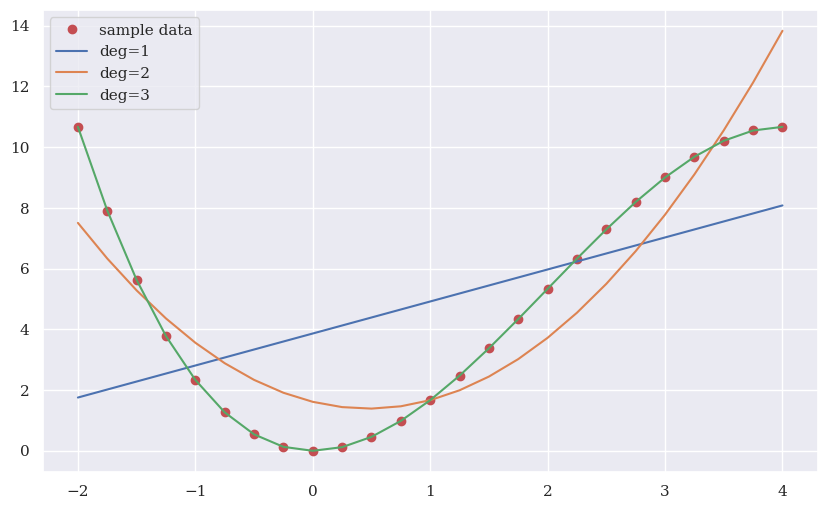

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for deg in [1, 2, 3]:
  reg = np.polyfit(x, y, deg=deg)
  y_ = np.polyval(reg, x)
  MSE = ((y - y_) ** 2).mean()
  print(f'deg={deg} | MSE={MSE:.5f}')
  plt.plot(x, np.polyval(reg, x), label=f'deg={deg}')
plt.legend();

In [ ]:
reg

array([-0.3333,  2.    ,  0.    , -0.    ])

Estimation with Neural Networks - Skit-Learn

In [ ]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=3 * [256],
                     learning_rate_init=0.03,
                     max_iter=5000)

In [ ]:
model.fit(x.reshape(-1, 1), y)
y_ = model.predict(x.reshape(-1, 1))

In [ ]:
MSE = ((y - y_) ** 2).mean()
MSE

np.float64(0.01045636435709229)

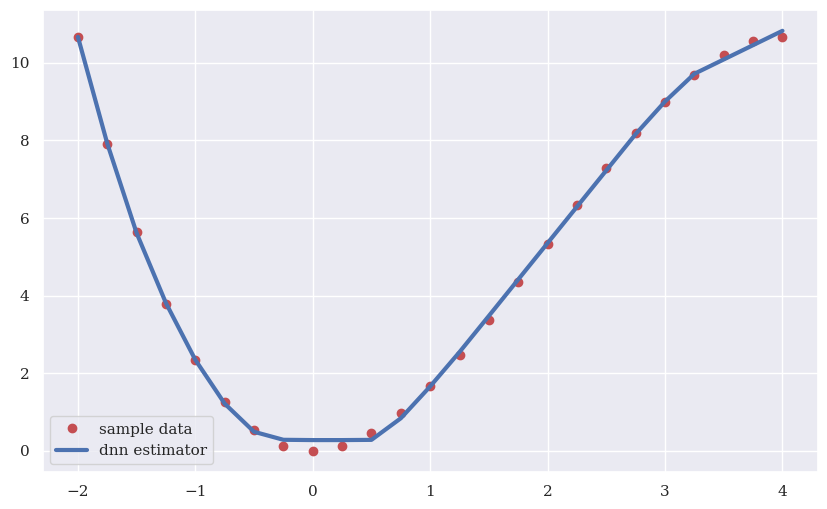

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
plt.plot(x, y_, lw=3.0, label='dnn estimator')
plt.legend();

In [ ]:
import tensorflow as tf
tf.random.set_seed(100)

Keras - Deep learning package.
Model is fitted, trained for 100 epochs. The procedure is done for 5 rounds.

In [ ]:
from keras.layers import Dense
from keras.models import Sequential
#Using TensorFlow backend.

In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=(1)))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='rmsprop')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
((y - y_) ** 2).mean()

np.float64(0.01045636435709229)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
round=1 | MSE=3.13434
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
round=2 | MSE=0.80388
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
round=3 | MSE=0.26080
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
round=4 | MSE=0.11800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
round=5 | MSE=0.08014


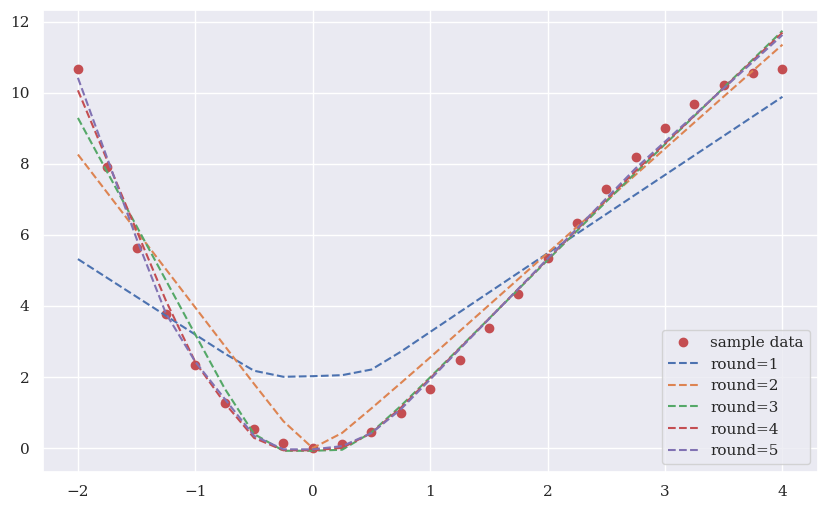

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for _ in range(1, 6):
  model.fit(x, y, epochs=100, verbose=False)
  y_ = model.predict(x)
  MSE = ((y - y_.flatten()) ** 2).mean()
  print(f'round={_} | MSE={MSE:.5f}')
  plt.plot(x, y_, '--', label=f'round={_}')
plt.legend();

Code creates the OLS regression estimation based on a varying number on monomial basis functions. Visualizing the results

In [ ]:
np.random.seed(0)
x = np.linspace(-1, 1)
y = np.random.random(len(x)) * 2 - 1

deg= 1 | MSE=0.28153
deg= 5 | MSE=0.27331
deg= 9 | MSE=0.25442
deg=11 | MSE=0.23458
deg=13 | MSE=0.22989
deg=15 | MSE=0.21672


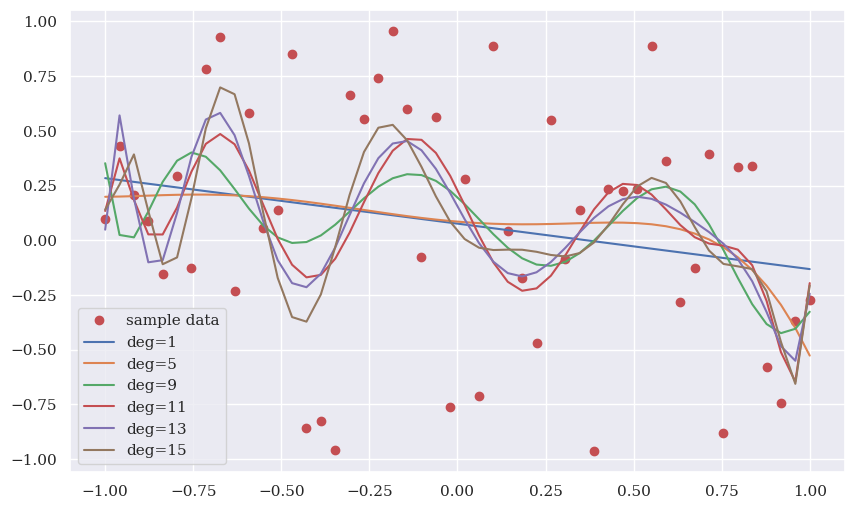

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for deg in [1,5,9,11,13,15]:
  reg = np.polyfit(x, y, deg=deg)
  y_ = np.polyval(reg, x)
  MSE = ((y - y_) ** 2).mean()
  print(f'deg={deg:2d} | MSE={MSE:.5f}')
  plt.plot(x, np.polyval(reg, x), label=f'deg={deg}')
plt.legend();

Random sample and neural network estimations

In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=(1)))
for _ in range(3):
  model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='rmsprop')

In [ ]:
model.summary()
Model:"sequential_2"

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,145 (774.00 KB)

 Trainable params: 198,145 (774.00 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
round=1 | MSE=0.13348
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
round=2 | MSE=0.08371
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
round=3 | MSE=0.11586
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
round=4 | MSE=0.06625
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
round=5 | MSE=0.03630
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
round=6 | MSE=0.05489
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
round=7 | MSE=0.00716
CPU times: user 2min 16s, sys: 4.49 s, total: 2min 20s
Wall time: 2min 15s


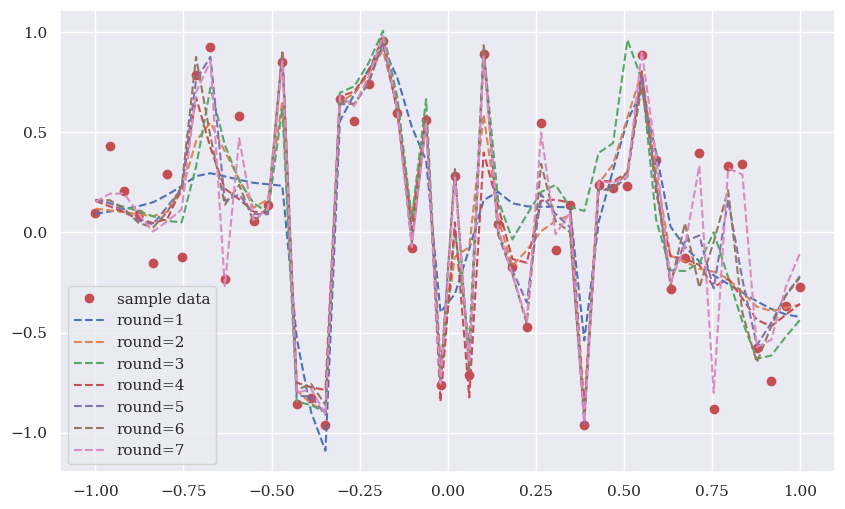

In [ ]:
%%time
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for _ in range(1, 8):
  model.fit(x, y, epochs=500, verbose=False)
  y_ = model.predict(x)
  MSE = ((y - y_.flatten()) ** 2).mean()
  print(f'round={_} | MSE={MSE:.5f}')
  plt.plot(x, y_, '--', label=f'round={_}')
plt.legend();

Classification with Neural Networks

In [ ]:
f =5
n =10

np.random.seed(100)

In [ ]:
x = np.random.randint(0,2,(n,f))
x

array([[0, 0, 1, 1, 1],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 1],
       [0, 1, 0, 0, 0],
       [1, 1, 1, 0, 0],
       [1, 0, 0, 1, 1],
       [1, 1, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 0, 1]])

In [ ]:
y = np.random.randint(0,2,n)
y

array([1, 1, 0, 0, 1, 1, 0, 1, 0, 1])

In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=(f)))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop',metrics=['acc'])

In [ ]:
n = 10
f = 5
x = np.random.randint(0,2,(n,f))
y = np.random.randint(0,2,n)
h = model.fit(x ,y ,epochs=50, verbose=False)

In [ ]:
y_ = np.where(model.predict(x).flatten() > 0.5, 1, 0)
y_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
y = y_

In [ ]:
res = pd.DataFrame(h.history)

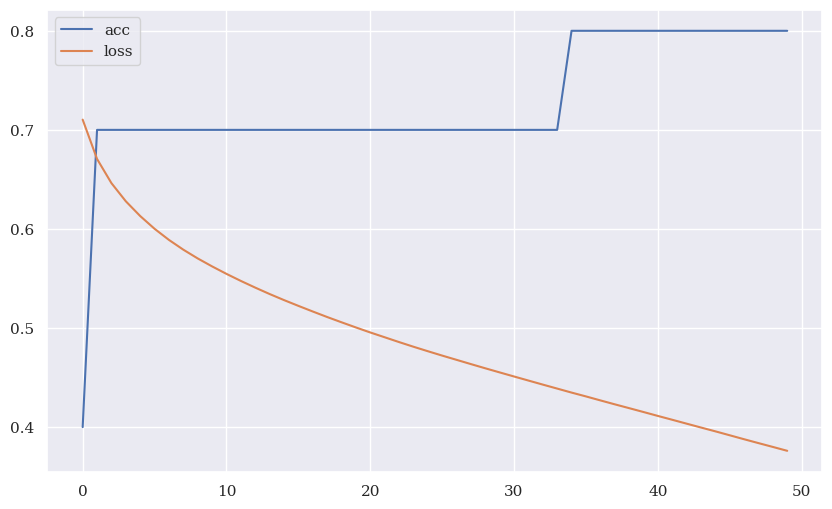

In [ ]:
res.plot(figsize=(10,6));

Small Data set

In [ ]:
f = 10
n = 250
np.random.seed(100)
x = np.random.randint(0,2,(n,f))
x[:4]
y = np.random.randint(0,2,n)
y[:4]

array([0, 1, 0, 0])

In [ ]:
2 ** f

1024

In [ ]:
fcols = [f'f{_}' for _ in range(f)]
fcols

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']

In [ ]:
data = pd.DataFrame(x, columns=fcols)
data['l']= y

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   f0      250 non-null    int64
 1   f1      250 non-null    int64
 2   f2      250 non-null    int64
 3   f3      250 non-null    int64
 4   f4      250 non-null    int64
 5   f5      250 non-null    int64
 6   f6      250 non-null    int64
 7   f7      250 non-null    int64
 8   f8      250 non-null    int64
 9   f9      250 non-null    int64
 10  l       250 non-null    int64
dtypes: int64(11)
memory usage: 21.6 KB


In [ ]:
grouped = data.groupby(list(data.columns))

In [ ]:
freq =grouped['l'].size().unstack(fill_value=0)

In [ ]:
freq['sum'] = freq[0] + freq[1]

In [ ]:
freq.head(10)

l                              0  1  sum
f0 f1 f2 f3 f4 f5 f6 f7 f8 f9           
0  0  0  0  0  0  0  1  1  1   0  1    1
                  1  0  1  0   1  1    2
                           1   0  1    1
               1  0  0  0  0   1  0    1
                           1   0  1    1
                     1  1  1   0  1    1
                  1  0  0  0   0  1    1
                        1  0   0  1    1
            1  0  0  0  1  1   1  0    1
                  1  1  0  0   1  0    1

In [ ]:
freq['sum'].describe().astype(int)

,sum
count,227
mean,1
std,0
min,1
25%,1
50%,1
75%,1
max,2


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [ ]:
model = MLPClassifier(hidden_layer_sizes=[128, 128,128], max_iter=1000, random_state=100)

In [ ]:
model.fit(data[fcols],data['l'])
MLPClassifier(hidden_layer_sizes=[128,128,128], max_iter=1000, random_state=100)

MLPClassifier(hidden_layer_sizes=[128, 128, 128], max_iter=1000,
              random_state=100)

In [ ]:
accuracy_score(data['l'],model.predict(data[fcols]))

0.952

In [ ]:
split = int(len(data)* 0.7)

In [ ]:
train = data[:split]
test = data[split:]

In [ ]:
model.fit(train[fcols], train['l'])
MLPClassifier(hidden_layer_sizes=[128,128,128], max_iter=1000, random_state=100)

MLPClassifier(hidden_layer_sizes=[128, 128, 128], max_iter=1000,
              random_state=100)

In [64]:
accuracy_score(train['l'],model.predict(train[fcols]))

0.9714285714285714

In [66]:
accuracy_score(test['l'],model.predict(test[fcols]))

0.38666666666666666

BIG SET

In [67]:
factor = 50
big = pd.DataFrame(np.random.randint(0,2,(factor * n,f)), columns=fcols)
big['l'] =  np.random.randint(0,2,factor * n)

In [69]:
train = big[:split]
test = big[split:]

In [70]:
model.fit(train[fcols], train['l'])
MLPClassifier(hidden_layer_sizes=[128,128,128], max_iter=1000, random_state=100)

MLPClassifier(hidden_layer_sizes=[128, 128, 128], max_iter=1000,
              random_state=100)

In [71]:
accuracy_score(train['l'],model.predict(train[fcols]))

0.9657142857142857

In [73]:
accuracy_score(test['l'],model.predict(test[fcols]))

0.5043407707910751

In [74]:
grouped = big.groupby(list(big.columns))
freq =grouped['l'].size().unstack(fill_value=0)
freq['sum'] = freq[0] + freq[1]
freq.head(6)

l                               0  1  sum
f0 f1 f2 f3 f4 f5 f6 f7 f8 f9            
0  0  0  0  0  0  0  0  0  0   10  9   19
                           1    5  4    9
                        1  0    2  5    7
                           1    6  6   12
                     1  0  0    9  8   17
                           1    7  4   11

In [75]:
freq['sum'].describe().astype(int)

,sum
count,1024
mean,12
std,3
min,2
25%,10
50%,12
75%,15
max,26


In [76]:
8 ** 25

37778931862957161709568